In [1]:
!pip install biopython networkx pandas numpy matplotlib seaborn scipy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 6.4 MB/s  0:00:00 eta 0:00:01m

[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import os
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

from Bio.PDB import PDBList, PDBParser
from Bio.PDB.Polypeptide import is_aa

In [3]:
# 1. Scaricare PDB 3NJP
PDB_ID = "3NJP"
DATA_DIR = "data"
os.makedirs(DATA_DIR, exist_ok=True)

pdbl = PDBList()
pdb_file = pdbl.retrieve_pdb_file(PDB_ID, pdir=DATA_DIR, file_format="pdb")

print("Downloaded file:", pdb_file)

Downloaded file: data/pdb3njp.ent


In [4]:
# 2. Leggere la struttura
parser = PDBParser(QUIET=True)
structure = parser.get_structure(PDB_ID, pdb_file)

print(structure)

<Structure id=3NJP>


In [5]:
# 3. Identificare modelli, catene, residui
model = structure[0]

chains = list(model.get_chains())
print("Chains found:", [chain.id for chain in chains])

for chain in chains:
    residues = [res for res in chain.get_residues() if is_aa(res, standard=True)]
    print(f"Chain {chain.id}: {len(residues)} amino-acid residues")

Chains found: ['A', 'B', 'C', 'D']
Chain A: 614 amino-acid residues
Chain B: 614 amino-acid residues
Chain C: 47 amino-acid residues
Chain D: 47 amino-acid residues


In [6]:
# 4. Estrarre tabella dei residui
residue_rows = []

for chain in chains:
    for res in chain.get_residues():
        if not is_aa(res, standard=True):
            continue
        
        hetflag, resseq, icode = res.id
        residue_rows.append({
            "chain": chain.id,
            "resseq": resseq,
            "icode": icode.strip(),
            "resname": res.get_resname(),
            "n_atoms": len(list(res.get_atoms()))
        })

residue_df = pd.DataFrame(residue_rows)
residue_df.head()

,chain,resseq,icode,resname,n_atoms
0,A,1,,LEU,8
1,A,2,,GLU,9
2,A,3,,GLU,9
3,A,4,,LYS,9
4,A,5,,LYS,9


In [7]:
# Statistiche 
residue_df.groupby("chain").agg(
    n_residues=("resseq", "count"),
    first_resseq=("resseq", "min"),
    last_resseq=("resseq", "max")
)

,n_residues,first_resseq,last_resseq
chain,,,
A,614,1,614
B,614,1,614
C,47,5,51
D,47,5,51


In [8]:
# 5. Controllo preliminare missing residues
def find_numbering_gaps(residue_df, chain_id):
    chain_df = residue_df[residue_df["chain"] == chain_id].sort_values("resseq")
    positions = chain_df["resseq"].unique()
    
    gaps = []
    for a, b in zip(positions[:-1], positions[1:]):
        if b - a > 1:
            gaps.append((a, b, b - a - 1))
    return gaps

for chain_id in residue_df["chain"].unique():
    gaps = find_numbering_gaps(residue_df, chain_id)
    print(f"Chain {chain_id} gaps:", gaps[:10], "..." if len(gaps) > 10 else "")

Chain A gaps: [] 
Chain B gaps: [] 
Chain C gaps: [] 
Chain D gaps: [] 


In [9]:
# 6. Scegliere due catene
CONTACT_CUTOFF = 4.5  # Angstrom

def get_heavy_atoms(residue):
    atoms = []
    for atom in residue.get_atoms():
        # Esclude idrogeni, se presenti
        if atom.element != "H":
            atoms.append(atom)
    return atoms

def residue_min_distance(res1, res2):
    atoms1 = get_heavy_atoms(res1)
    atoms2 = get_heavy_atoms(res2)
    
    if len(atoms1) == 0 or len(atoms2) == 0:
        return np.inf
    
    min_dist = np.inf
    for a1 in atoms1:
        coord1 = a1.coord
        for a2 in atoms2:
            dist = np.linalg.norm(coord1 - a2.coord)
            if dist < min_dist:
                min_dist = dist
    return min_dist

def get_aa_residues(chain):
    return [res for res in chain.get_residues() if is_aa(res, standard=True)]

In [12]:
# Scansione coppie catene:
chain_dict = {chain.id: chain for chain in chains}
chain_ids = list(chain_dict.keys())

pair_summary = []

for i, c1 in enumerate(chain_ids):
    for c2 in chain_ids[i+1:]:
        residues1 = get_aa_residues(chain_dict[c1])
        residues2 = get_aa_residues(chain_dict[c2])
        
        n_contacts = 0
        
        for r1 in residues1:
            for r2 in residues2:
                d = residue_min_distance(r1, r2)
                if d <= CONTACT_CUTOFF:
                    n_contacts += 1
        
        pair_summary.append({
            "chain_1": c1,
            "chain_2": c2,
            "n_contacts": n_contacts
        })

pair_df = pd.DataFrame(pair_summary).sort_values("n_contacts", ascending=False)
pair_df

,chain_1,chain_2,n_contacts
4,B,D,88
1,A,C,87
0,A,B,73
2,A,D,0
3,B,C,0
5,C,D,0


In [13]:
# 7. Calcolare tabella contatti per la coppia scelta
CHAIN_A = pair_df.iloc[0]["chain_1"]
CHAIN_B = pair_df.iloc[0]["chain_2"]

print("Selected chains:", CHAIN_A, CHAIN_B)

residues_A = get_aa_residues(chain_dict[CHAIN_A])
residues_B = get_aa_residues(chain_dict[CHAIN_B])

Selected chains: B D


In [14]:
# Funzione per creare un identificatore leggibile del residuo:
def residue_id(chain_id, residue):
    hetflag, resseq, icode = residue.id
    resname = residue.get_resname()
    icode = icode.strip()
    return f"{chain_id}:{resname}{resseq}{icode}"

In [15]:
# Tabella contatti:
contacts = []

for r1 in residues_A:
    for r2 in residues_B:
        d = residue_min_distance(r1, r2)
        if d <= CONTACT_CUTOFF:
            contacts.append({
                "chain_1": CHAIN_A,
                "residue_1": residue_id(CHAIN_A, r1),
                "resseq_1": r1.id[1],
                "resname_1": r1.get_resname(),
                "chain_2": CHAIN_B,
                "residue_2": residue_id(CHAIN_B, r2),
                "resseq_2": r2.id[1],
                "resname_2": r2.get_resname(),
                "min_distance_A": d
            })

contacts_df = pd.DataFrame(contacts).sort_values("min_distance_A")
contacts_df.head(20)

,chain_1,residue_1,resseq_1,resname_1,chain_2,residue_2,resseq_2,resname_2,min_distance_A
63,B,B:GLN384,384,GLN,D,D:ARG45,45,ARG,2.602119
21,B,B:GLY18,18,GLY,D,D:CYS33,33,CYS,2.856585
61,B,B:GLN384,384,GLN,D,D:GLN43,43,GLN,2.862628
31,B,B:GLU90,90,GLU,D,D:LYS28,28,LYS,2.887887
13,B,B:THR15,15,THR,D,D:GLU40,40,GLU,2.890513
49,B,B:SER356,356,SER,D,D:ASP11,11,ASP,2.930973
14,B,B:GLN16,16,GLN,D,D:CYS31,31,CYS,2.933968
16,B,B:GLN16,16,GLN,D,D:CYS33,33,CYS,2.982887
22,B,B:ASP22,22,ASP,D,D:VAL35,35,VAL,3.005553
20,B,B:GLY18,18,GLY,D,D:ASN32,32,ASN,3.034004


In [16]:
# Statistiche:
print("Number of residue-residue contacts:", len(contacts_df))
print("Interface residues in chain", CHAIN_A, ":", contacts_df["residue_1"].nunique())
print("Interface residues in chain", CHAIN_B, ":", contacts_df["residue_2"].nunique())

Number of residue-residue contacts: 88
Interface residues in chain B : 43
Interface residues in chain D : 31


In [17]:
# 8. Matrice contatti
contact_matrix = contacts_df.pivot_table(
    index="residue_1",
    columns="residue_2",
    values="min_distance_A",
    aggfunc="min"
)

contact_matrix.head()

residue_2,D:ALA25,D:ALA30,D:ARG41,D:ARG45,D:ASN32,D:ASP11,D:ASP46,D:CYS31,D:CYS33,D:GLN43,...,D:LYS28,D:LYS48,D:MET21,D:SER9,D:TRP49,D:TRP50,D:TYR13,D:TYR37,D:TYR44,D:VAL35
residue_1,,,,,,,,,,,,,,,,,,,,,
B:ALA415,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
B:ALA68,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
B:ARG29,NaN,NaN,NaN,NaN,NaN,NaN,4.204962,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,3.30783,NaN,NaN,NaN,NaN,NaN
B:ARG353,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
B:ASN12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


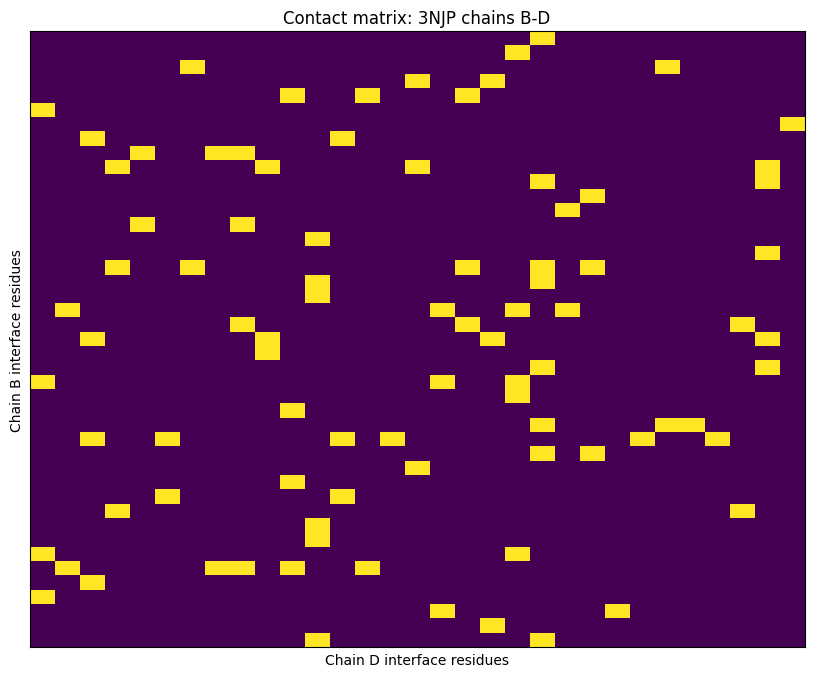

In [18]:
# Visualizzazione semplice:
plt.figure(figsize=(10, 8))
plt.imshow(~contact_matrix.isna(), aspect="auto")
plt.xlabel(f"Chain {CHAIN_B} interface residues")
plt.ylabel(f"Chain {CHAIN_A} interface residues")
plt.title(f"Contact matrix: {PDB_ID} chains {CHAIN_A}-{CHAIN_B}")
plt.xticks([])
plt.yticks([])
plt.show()

In [19]:
# 9. Costruire il grafo residue-level
G = nx.Graph()

for _, row in contacts_df.iterrows():
    r1 = row["residue_1"]
    r2 = row["residue_2"]
    
    G.add_node(
        r1,
        chain=row["chain_1"],
        resseq=int(row["resseq_1"]),
        resname=row["resname_1"]
    )
    
    G.add_node(
        r2,
        chain=row["chain_2"],
        resseq=int(row["resseq_2"]),
        resname=row["resname_2"]
    )
    
    G.add_edge(
        r1,
        r2,
        distance=float(row["min_distance_A"])
    )

print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())

Nodes: 74
Edges: 88


In [20]:
# Statistiche di centralità:
degree_dict = dict(G.degree())
betweenness_dict = nx.betweenness_centrality(G)

node_stats = []

for node in G.nodes():
    node_stats.append({
        "node": node,
        "chain": G.nodes[node]["chain"],
        "resname": G.nodes[node]["resname"],
        "resseq": G.nodes[node]["resseq"],
        "degree": degree_dict[node],
        "betweenness": betweenness_dict[node]
    })

node_stats_df = pd.DataFrame(node_stats).sort_values(
    ["degree", "betweenness"],
    ascending=False
)

node_stats_df.head(20)

,node,chain,resname,resseq,degree,betweenness
37,D:LEU47,D,LEU,47,8,0.382768
22,B:PHE357,B,PHE,357,6,0.131976
43,D:GLU51,D,GLU,51,6,0.104452
36,B:HIS409,B,HIS,409,5,0.465986
7,B:THR15,B,THR,15,5,0.343980
39,D:TYR44,D,TYR,44,5,0.254524
20,D:LEU26,D,LEU,26,5,0.135084
30,B:LEU14,B,LEU,14,4,0.297374
70,B:LEU325,B,LEU,325,4,0.276790
0,B:GLN384,B,GLN,384,4,0.219768


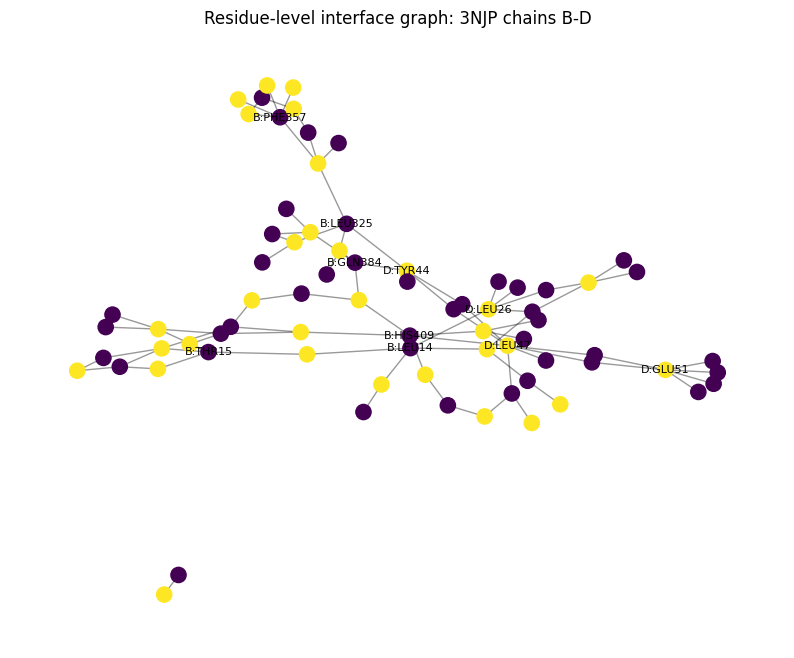

In [21]:
# 10. Visualizzare il grafo
plt.figure(figsize=(10, 8))

pos = nx.spring_layout(G, seed=42)

node_colors = [
    0 if G.nodes[n]["chain"] == CHAIN_A else 1
    for n in G.nodes()
]

nx.draw_networkx_nodes(G, pos, node_size=120, node_color=node_colors)
nx.draw_networkx_edges(G, pos, alpha=0.4)

# Etichettiamo solo i nodi più connessi
top_nodes = node_stats_df.head(10)["node"].tolist()
labels = {n: n for n in top_nodes}

nx.draw_networkx_labels(G, pos, labels=labels, font_size=8)

plt.title(f"Residue-level interface graph: {PDB_ID} chains {CHAIN_A}-{CHAIN_B}")
plt.axis("off")
plt.show()

In [22]:
# 11. Esportare i risultati
OUTPUT_DIR = "outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

contacts_df.to_csv(os.path.join(OUTPUT_DIR, "contacts.csv"), index=False)
node_stats_df.to_csv(os.path.join(OUTPUT_DIR, "interface_nodes.csv"), index=False)

nx.write_graphml(G, os.path.join(OUTPUT_DIR, "interface_graph.graphml"))

print("Saved outputs in:", OUTPUT_DIR)

Saved outputs in: outputs


 
## Preliminary interpretation

In this notebook, the EGFR kinase dimer structure was downloaded from the PDB and converted into a residue-level protein-interface graph. Chains X and Y were selected based on the number of inter-chain contacts. Interface contacts were defined using a heavy-atom distance cutoff of 4.5 Å.

Each node in the graph represents an amino-acid residue, and each edge represents a spatial contact between residues belonging to different chains. Edge weights encode the minimum heavy-atom distance between the two residues.

Residues with high graph degree may represent structurally central interface residues. These residues are not yet energetic hotspots, but they provide a first graph-based approximation of the interaction core. In the next step, this graph can be used for subgraph search, hotspot prioritization, and peptide-fragment extraction.